In [1]:
graph = {
    0: [(1, 4), (2, 2)],
    1: [(0, 4), (2, 1), (3, 5)],
    2: [(0, 2), (1, 1), (3, 8)],
    3: [(1, 5), (2, 8)]
}

parcels = [
    {"id": 1, "weight": 5, "deadline": 10},
    {"id": 2, "weight": 10, "deadline": 5},
    {"id": 3, "weight": 3, "deadline": 8}
]

vehicle_capacity = 15

In [2]:
def route_cost(path, graph):
    if len(path) <= 1:
        return 0
    
    cost = 0
    for i in range(len(path)-1):
        for neighbor, weight in graph[path[i]]:
            if neighbor == path[i+1]:
                cost += weight
    
    return cost

path = [0, 2, 1, 3]
print("Route Cost:", route_cost(path, graph))

Route Cost: 8


In [3]:
def greedy_parcels(parcels, capacity):
    parcels.sort(key=lambda x: x["deadline"])
    
    selected = []
    total_weight = 0
    
    for p in parcels:
        if total_weight + p["weight"] <= capacity:
            selected.append(p)
            total_weight += p["weight"]
    
    return selected

selected = greedy_parcels(parcels, vehicle_capacity)
print("Selected Parcels:", selected)

Selected Parcels: [{'id': 2, 'weight': 10, 'deadline': 5}, {'id': 3, 'weight': 3, 'deadline': 8}]


In [4]:
def dp_parcel_selection(parcels, capacity):
    n = len(parcels)
    dp = [[0]*(capacity+1) for _ in range(n+1)]
    
    for i in range(1, n+1):
        w = parcels[i-1]["weight"]
        
        for c in range(capacity+1):
            if w <= c:
                dp[i][c] = max(dp[i-1][c], 1 + dp[i-1][c-w])
            else:
                dp[i][c] = dp[i-1][c]
    
    return dp[n][capacity]

print("Max Parcels (DP):", dp_parcel_selection(parcels, vehicle_capacity))

Max Parcels (DP): 2


In [5]:
import heapq

def dijkstra(graph, start):
    dist = {node: float('inf') for node in graph}
    dist[start] = 0
    
    pq = [(0, start)]
    
    while pq:
        d, node = heapq.heappop(pq)
        
        for neighbor, weight in graph[node]:
            new_d = d + weight
            
            if new_d < dist[neighbor]:
                dist[neighbor] = new_d
                heapq.heappush(pq, (new_d, neighbor))
    
    return dist

print("Shortest Paths:", dijkstra(graph, 0))

Shortest Paths: {0: 0, 1: 3, 2: 2, 3: 8}


In [6]:
import itertools

def tsp(graph):
    nodes = list(graph.keys())
    min_cost = float('inf')
    best_path = []

    for perm in itertools.permutations(nodes[1:]):
        path = [0] + list(perm) + [0]
        cost = route_cost(path, graph)
        
        if cost < min_cost:
            min_cost = cost
            best_path = path
    
    return best_path, min_cost

path, cost = tsp(graph)

print("Best Route:", path)
print("Total Distance:", cost)

Best Route: [0, 2, 1, 3, 0]
Total Distance: 8


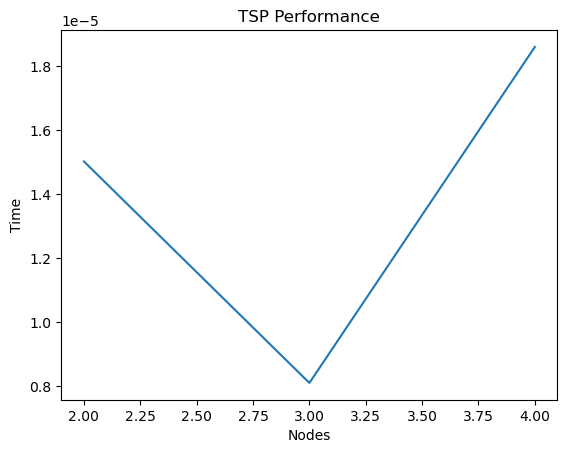

In [7]:
import matplotlib.pyplot as plt
import time

sizes = [2, 3, 4]
times = []

for n in sizes:
    small_graph = {i: [(j, 1) for j in range(n) if j != i] for i in range(n)}
    
    start = time.time()
    tsp(small_graph)
    times.append(time.time() - start)

plt.plot(sizes, times)
plt.title("TSP Performance")
plt.xlabel("Nodes")
plt.ylabel("Time")
plt.show()